#### **Exercise 2 (a)**: Generate predictions for Spanish Clitic Doubling example item

1. Dative
	- Laura dio flores a Rafael en el parque de las afueras de la ciudad.

1. Dative_doubled:
	- Laura le dio flores a Rafael en el parque de las afueras de la ciudad.

1. Accusative:
	- Laura encontró a Rafael en el parque de las afueras de la ciudad.

1. Accusative_doubled:
	- Laura lo encontró a Rafael en el parque de las afueras de la ciudad.


In [ ]:
!pip install minicons
!pip install nltk
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install transformers
!pip install huggingface_hub
!pip install diffusers
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 10.6 MB/s eta 0:00:00


In [ ]:
# Import "scorer" module from the minicons library
from minicons import scorer

# Load helper functions from the file helper_functions.py
from helper_functions import *

In [ ]:
# Model for Spanish
model_name_es = "goldfish-models/spa_latn_1000mb"

# model_name_es = "surus-lat/Llama-3.1-Tango-70b-bnb_4b"

# Load the specified model IncrementalLMScorer is a wrapper around any causal (autoregressive) language model accessible via Hugging Face’s transformers.
lmScorer_es = scorer.IncrementalLMScorer(model_name_es)

BOS_es = initialize_bos(model_name_es)

<br>
<br>

#### **Exercise 2 (b)**: Generate predictions for all items
- See file: `experiment_items/Items_Spanish_clitic_doubling.csv`

In [ ]:
dative = "Laura le dio un regalo a Ra"
dative_doubled = "The key to the cabinets was rusty from many years of disuse."
accusative = "The key to the cabinet were rusty from many years of disuse."
accusative_doubled = "The key to the cabinets were rusty from many years of disuse."

<BR>
<BR>

#### **Exercise 2 (c)**: Calculate and check mean surprisal by condition


In [27]:
items_source_file = "Items_Spanish_clitic_doubling.csv"
items_dest_file = "Items_Spanish_clitic_doubling_surprisal.csv"


# Function that reads the whole csv file
get_word_surprisal_csv(lmScorer_es,
                       BOS=BOS_es,
                       input_csv=items_source_file,
                       sentence_col="Sentence",

                       # specify the target word
                       word_col="Target",

                       # you sceptify the  output filefile
                       output_csv=items_dest_file
                       )



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
# Import function to read the csv file
import pandas as pd

In [29]:
# Read the CSV file with surprisal values
df_spanish = pd.read_csv(items_dest_file)

# Calculate mean surprisal by condition
condition_order = ["dative", "dative_doubled", "accusative", "accusative_doubled"]
df_spanish.groupby('Condition')['surprisal'].mean().reindex(condition_order)

,surprisal
Condition,
dative,9.315901
dative_doubled,8.335864
accusative,8.174692
accusative_doubled,9.752842


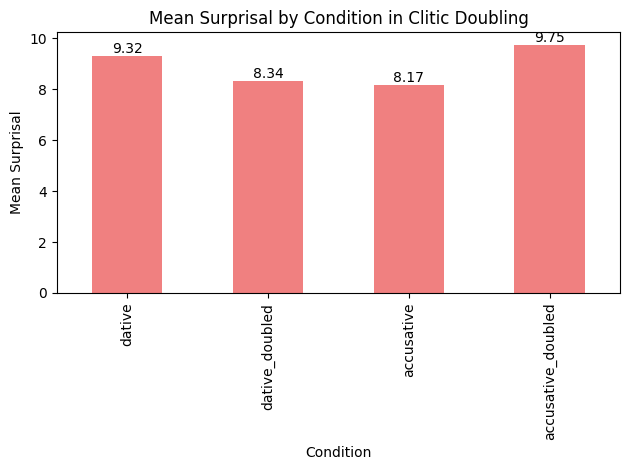

In [30]:
means = df_spanish.groupby('Condition')['surprisal'].mean().reindex(condition_order)

means.plot(kind='bar', color='lightcoral')

for i, val in enumerate(means):
    plt.text(i, val, f'{val:.2f}', ha='center', va='bottom')

plt.ylabel('Mean Surprisal')
plt.title('Mean Surprisal by Condition in Clitic Doubling')
plt.tight_layout()
plt.show()
